# Churn model: what got trained and how good is it

The actual training happens in `src/ml/train.py` (run it first). This notebook digs into the results: model comparison, what features matter, and how to choose the probability threshold.

Quick recap of the setup: 60/20/20 train/validation/test split, stratified. Four candidates: an always-churn dummy (the floor every real model has to beat), logistic regression, random forest, gradient boosting. All with balanced class weights because 85% of customers churn.

In [4]:
import os, sys, json

if os.path.exists("work/src"):
    os.chdir("work")
elif os.path.exists("../src"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import joblib
import pandas as pd
import matplotlib.pyplot as plt

with open("models/metrics.json") as f:
    metrics = json.load(f)

pd.DataFrame([
    {"model": r["model"], "roc_auc": r["roc_auc"], "pr_auc": r["pr_auc"]}
    for r in metrics["validation"]
])

,model,roc_auc,pr_auc
0,always_churn_baseline,0.5000,0.8453
1,logistic_regression,0.6136,0.8889
2,random_forest,0.6162,0.8870
3,hist_gradient_boosting,0.6078,0.8915


## Why not accuracy?

The dummy model that predicts churn for literally everyone gets 85% accuracy here. Any metric where doing nothing scores 85% tells you nothing. That's why the comparison uses:

- **ROC-AUC**: probability that a random churner gets a higher risk score than a random non-churner. 0.5 = coin flip, 1.0 = perfect ranking.
- **PR-AUC**: like ROC-AUC but focused on the positive class. Important detail: its baseline is not 0.5 but the positive rate (0.845 here), so read it as lift above that, not as an absolute number.

The winner (random forest) scores about 0.62 ROC-AUC on test. Honest interpretation: the model ranks customers meaningfully better than chance, but far from perfectly. TheLook is generated data and its purchase behavior just doesn't contain strong comeback patterns. The pipeline around the model is built right, which is the part that transfers to real data.

## Which features does the model actually use?

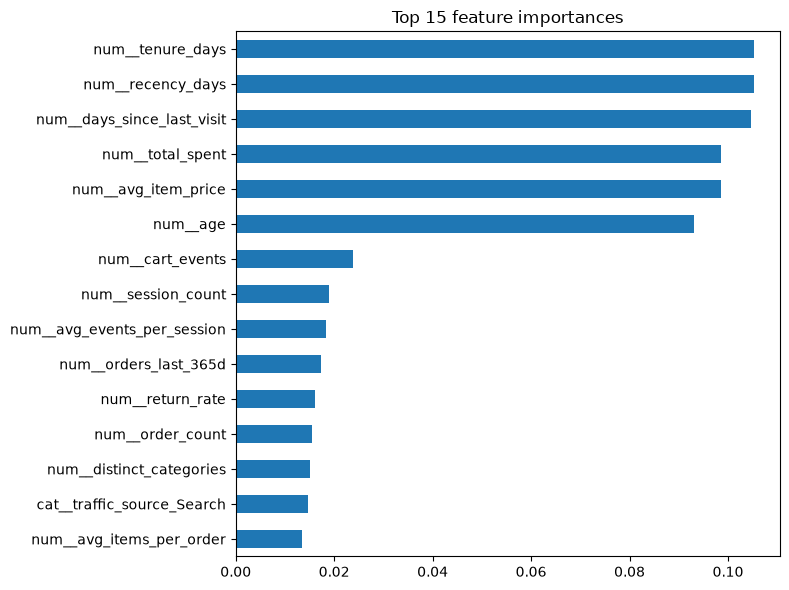

In [5]:
model = joblib.load("models/churn_model.joblib")
rf = model.named_steps["model"]
feature_names = model.named_steps["prep"].get_feature_names_out()

imp = (
    pd.Series(rf.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)
imp.sort_values().plot.barh(figsize=(8, 6), title="Top 15 feature importances")
plt.tight_layout()
plt.show()

Expect the behavioral features (recency, tenure, order counts, spend) at the top and the one-hot state/gender columns near the bottom. Demographics rarely beat behavior.

## Choosing the threshold

The model outputs a probability. Turning that into a yes/no decision means picking a cutoff, and 0.5 is not sacred. Where you put it depends on what a retention campaign costs versus what a lost customer costs.

Say the marketing budget only reaches 20% of customers: then the right move is to sort everyone by churn probability and target the top 20%, and the threshold falls out of the budget instead of the other way around.

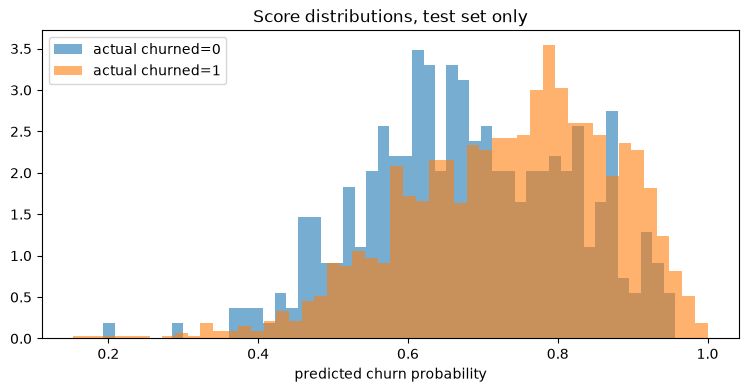

In [6]:
scores = pd.read_parquet("data/processed/churn_scores.parquet")
held_out = scores[scores["split"] == "test"]

plt.figure(figsize=(9, 4))
for label, grp in held_out.groupby("churned"):
    plt.hist(grp["churn_probability"], bins=50, alpha=0.6,
             label=f"actual churned={label}", density=True)
plt.xlabel("predicted churn probability")
plt.legend()
plt.title("Score distributions, test set only")
plt.show()

The scores file contains every customer because the dashboard serves all of them, but this plot deliberately filters to the test split. Training rows would show a far cleaner separation than the model really has, a random forest scores rows it was trained on almost perfectly, so held out customers are the only fair view. The overlap here is what a 0.62 AUC looks like in practice: the churned mass sits clearly further right, but there is no clean cutoff.

For the dashboard we keep the raw probability for all customers and let the viewer segment by it, instead of baking one threshold in.